## **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.layers import Input, Dense, Dropout
from keras import Sequential

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PowerTransformer

## **Functions**

In [ ]:
def create_keras_model():
  model = keras.Sequential()

  model.add(Input(shape=(13,)))

  model.add(Dense(32, activation='relu'))
  model.add(Dropout(0.2))

  model.add(Dense(32, activation='relu'))
  model.add(Dropout(0.2))

  model.add(Dense(1,activation='linear'))

  model.compile(optimizer='adam', loss='mse', metrics=[keras.metrics.R2Score, keras.metrics.RootMeanSquaredError])

  return model

In [ ]:
def visualize_keras_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(20, 5))

    ax[0].plot(history.history['loss'], label='loss')
    ax[0].plot(history.history['val_loss'], label='val_loss')
    ax[0].set_title('Model Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(history.history['r2_score'], label='r2_score')
    ax[1].plot(history.history['val_r2_score'], label='val_r2_score')
    ax[1].set_title('R² Score')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('R² Score')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()


## **Data splitting**

In [ ]:
d_train = pd.read_csv("./boston_dataset/train.csv")
d_train.drop('ID', axis=1, inplace=True)

print(d_train.shape)

d_train.sample(3)

(333, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
26,0.12269,0.0,6.91,0,0.448,6.069,40.0,5.7209,3,233,17.9,389.39,9.55,21.2
21,0.17505,0.0,5.96,0,0.499,5.966,30.2,3.8473,5,279,19.2,393.43,10.13,24.7
314,10.23300,0.0,18.10,0,0.614,6.185,96.7,2.1705,24,666,20.2,379.70,18.03,14.6


In [ ]:

X = d_train.copy()
y = X.pop('medv')

X.sample(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
233,0.07244,60.0,1.69,0,0.411,5.884,18.5,10.7103,4,411,18.3,392.33,7.79
279,6.44405,0.0,18.10,0,0.584,6.425,74.8,2.2004,24,666,20.2,97.95,12.03
49,0.19539,0.0,10.81,0,0.413,6.245,6.2,5.2873,4,305,19.2,377.17,7.54


## Data exploration

In [ ]:
# sns.pairplot(X, diag_kind='kde')
# plt.show()

<Axes: >

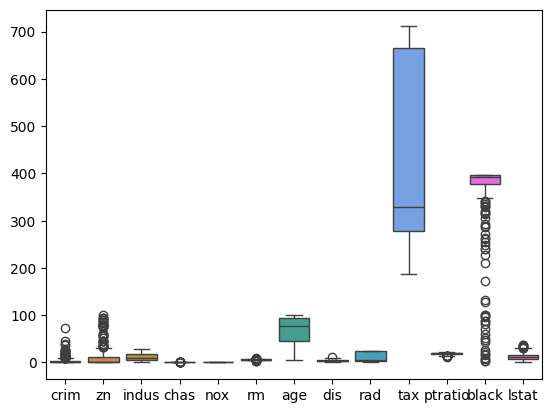

In [ ]:
sns.boxplot(X)

- skewed data
- outliers

Use `RobustScaler` with some kind of `log scaling`

In [ ]:
X.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,3.360341,10.689189,11.293483,0.060060,0.557144,6.265619,68.226426,3.709934,9.633634,409.279279,18.448048,359.466096,12.515435
std,7.352272,22.674762,6.998123,0.237956,0.114955,0.703952,28.133344,1.981123,8.742174,170.841988,2.151821,86.584567,7.067781
min,0.006320,0.000000,0.740000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,188.000000,12.600000,3.500000,1.730000
25%,0.078960,0.000000,5.130000,0.000000,0.453000,5.884000,45.400000,2.122400,4.000000,279.000000,17.400000,376.730000,7.180000
50%,0.261690,0.000000,9.900000,0.000000,0.538000,6.202000,76.700000,3.092300,5.000000,330.000000,19.000000,392.050000,10.970000
75%,3.678220,12.500000,18.100000,0.000000,0.631000,6.595000,93.800000,5.116700,24.000000,666.000000,20.200000,396.240000,16.420000
max,73.534100,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,21.200000,396.900000,37.970000


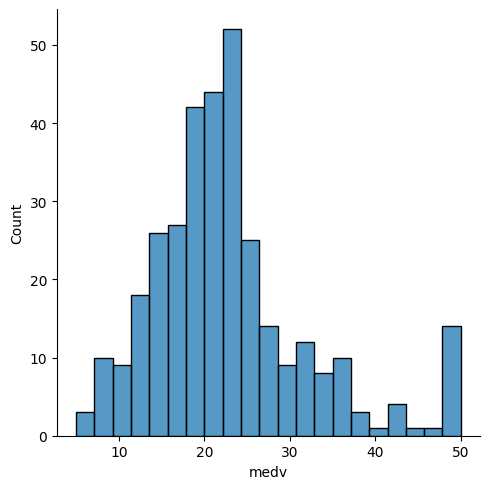

In [ ]:
sns.displot(y)

## Data preproccessing

In [ ]:
scaler = RobustScaler()
X = scaler.fit_transform(X)

transformer = PowerTransformer(method='yeo-johnson')
X = transformer.fit_transform(X)

X = pd.DataFrame(X)

In [ ]:
#sns.pairplot(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## Model training

In [ ]:
model = create_keras_model()

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(X_train,y_train, epochs=100, batch_size=2, verbose=0, callbacks=[early_stopping], validation_data=(X_val, y_val))

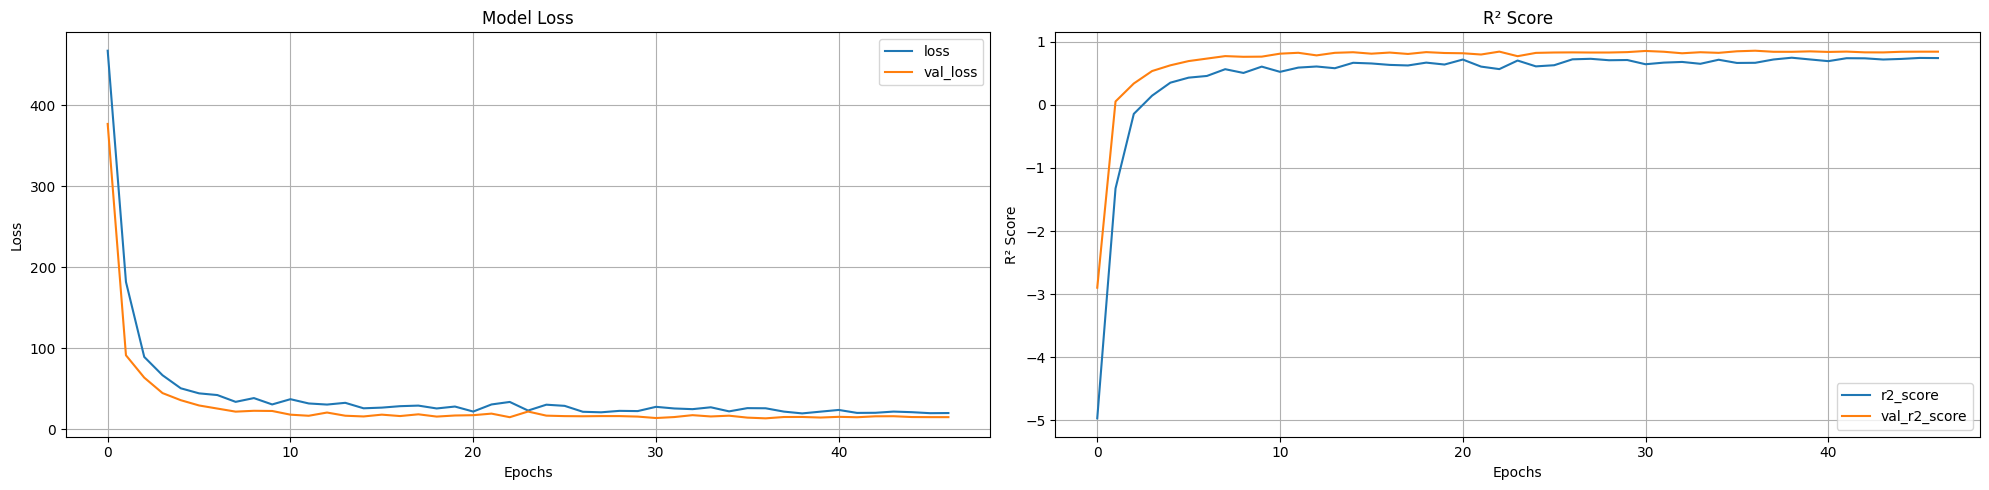

In [ ]:
visualize_keras_history(history)

In [ ]:
model.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 15.3447 - r2_score: 0.8354 - root_mean_squared_error: 3.9171 


[15.1759033203125, 0.831375777721405, 3.8956260681152344]